ТАБЛИЦА СТАТИСТИКИ
           mean     std      min      max    range
Apple    110.64   43.33    35.55   182.01   146.46
Market  3626.28  635.41  2237.40  4796.56  2559.16
VIX       22.52    8.72    11.54    82.69    71.15
Gold     158.54   18.23   119.94   193.89    73.95


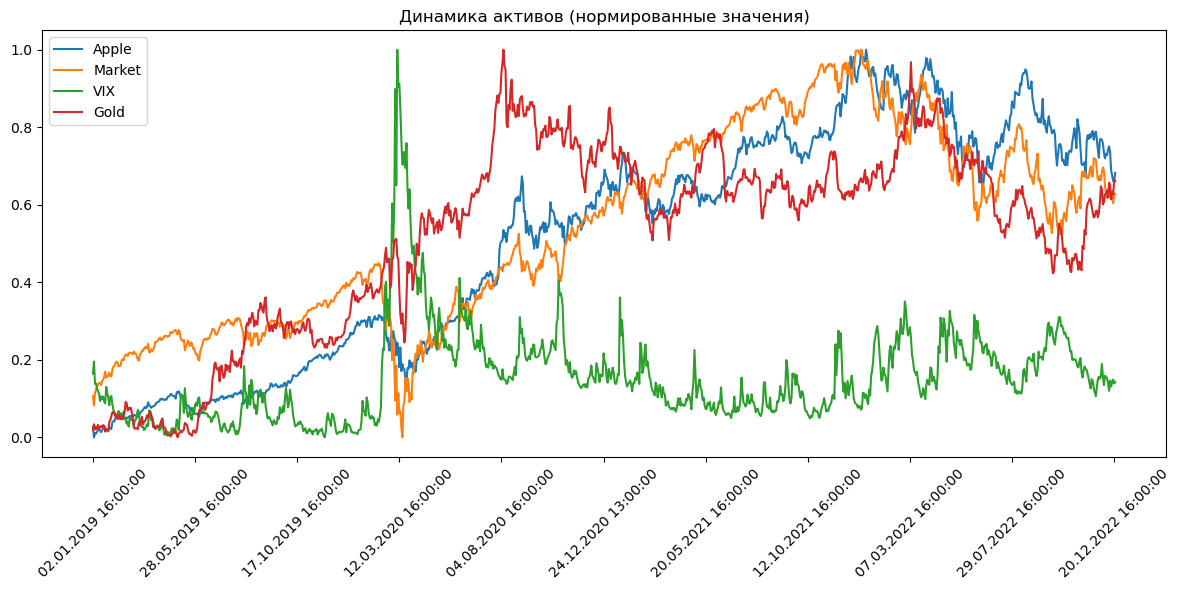

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cwfc.csv', sep=None, engine='python')

def get_column(i):
    s = df.iloc[:, i].astype(str).str.replace(',', '.').str.strip()
    return pd.to_numeric(s, errors='coerce').values

dates = df.iloc[:, 0].values
apple = get_column(1)
market = get_column(2)
vix = get_column(3)
gold = get_column(4)

import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
    'Apple': apple,
    'Market': market,
    'VIX': vix,
    'Gold': gold
}, index=dates).dropna()

stats = data.describe().transpose()
stats['range'] = stats['max'] - stats['min']
print("ТАБЛИЦА СТАТИСТИКИ")
print(stats[['mean', 'std', 'min', 'max', 'range']].round(2))

plt.figure(figsize=(12, 6))
for col in data.columns:
    plt.plot(data.index, (data[col] - data[col].min()) / (data[col].max() - data[col].min()), label=col)

plt.title('Динамика активов (нормированные значения)')
plt.legend()
plt.xticks(data.index[::100], rotation=45) # Показываем каждую 100-ю дату, чтобы не было каши
plt.tight_layout()
plt.show()